In [1]:
import os
import math
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from tensorflow.keras.callbacks import LearningRateScheduler

from utils import  evaluate_and_plot_predictions,asymmetric_profit_loss,set_seed,plot_training_history_with_lr,create_sequences
set_seed(42)

Сид установлен на 42 для Python, NumPy, TensorFlow и PYTHONHASHSEED.


#  Подготовка данных

In [2]:
df_features = pd.read_csv('data/features.csv')

target_col = 'consumption'
feature_cols = [col for col in df_features.columns if col not in ['timestamp', target_col]]

split_idx = int(len(df_features) * 0.8)
train_df = df_features.iloc[:split_idx].copy()
test_df = df_features.iloc[split_idx:].copy()

train_X_raw = train_df[feature_cols].values
test_X_raw = test_df[feature_cols].values

train_y_raw = train_df[target_col].values
test_y_raw = test_df[target_col].values

train_dates = pd.to_datetime(train_df['timestamp']).values
test_dates = pd.to_datetime(test_df['timestamp']).values

SEQ_LEN = 24  
HORIZON = 24   



X_train, y_train, dates_train = create_sequences(train_X_raw, train_y_raw, train_dates, SEQ_LEN, HORIZON)
X_test, y_test, dates_test = create_sequences(test_X_raw, test_y_raw, test_dates, SEQ_LEN, HORIZON)

# Стандартизация X

In [3]:
n_features = X_train.shape[2]
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_features)
X_test_2d  = X_test.reshape(-1, n_features)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(X_train_2d).reshape(X_train.shape)
X_test_scaled  = scaler.transform(X_test_2d).reshape(X_test.shape)

joblib.dump(scaler, 'model_weights/scaler_hybrid.joblib')

print(f"Обучающая выборка: {X_train_scaled.shape}")
print(f"Тестовая выборка:  {X_test_scaled.shape}")

Обучающая выборка: (6825, 24, 57)
Тестовая выборка:  (1672, 24, 57)


# Архитектура Hybrid network

In [4]:
def build_model_hybrid(input_shape):
    l2_reg = 1e-5
    inputs = layers.Input(shape=input_shape)

    #  CNN 
    x = layers.Conv1D(64, kernel_size=5, padding='same', activation='swish',
                      kernel_regularizer=regularizers.l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    
    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='swish',
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.MaxPooling1D(pool_size=2)(x) 

    #  RNN 
    x = layers.LSTM(128, return_sequences=True, 
                   kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.LayerNormalization()(x)
    
    x = layers.LSTM(64, return_sequences=True, 
                   kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.LayerNormalization()(x)

    #  ATTENTION 
    attention_out = layers.MultiHeadAttention(num_heads=8, key_dim=64)(x, x)
    x = layers.Add()([x, attention_out]) 
    x = layers.LayerNormalization()(x)

    # ГОЛОВА 
    x = layers.GlobalAveragePooling1D()(x)
    
    x = layers.Dense(128, activation='swish')(x)
    x = layers.Dense(64, activation='swish')(x)
    
    outputs = layers.Dense(HORIZON, activation='linear')(x)

    return models.Model(inputs=inputs, outputs=outputs, name="Hybrid_Deep_LSTM")

In [5]:
model_hybrid = build_model_hybrid((SEQ_LEN, n_features))

In [6]:
model_hybrid.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=5e-4, clipvalue=0.5), 
    loss=asymmetric_profit_loss, 
    metrics=['mae']
)

callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=30, 
        restore_best_weights=True, 
        verbose=1
    ),
    
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.75, 
        patience=10, 
        min_lr=1e-6, 
        verbose=1
    ),
    callbacks.TerminateOnNaN()
]

model_hybrid.summary()

Model: "Hybrid_Deep_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 57)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 64)    │     18,304 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 24, 128)   │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 12, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 12, 128)   │    131,584 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 12, 128)   │        256 │ lstm[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 12, 64)    │     49,408 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 64)    │        128 │ lstm_1[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 64)    │    132,672 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 12, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 24)        │      1,560 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 376,088 (1.43 MB)

 Trainable params: 375,704 (1.43 MB)

 Non-trainable params: 384 (1.50 KB)

In [7]:
history_hybrid = model_hybrid.fit(
    X_train_scaled, y_train,
    epochs=300,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - loss: 277.3015 - mae: 8.1342 - val_loss: 5.6198 - val_mae: 1.1284 - learning_rate: 5.0000e-04
Epoch 2/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.5604 - mae: 0.3646 - val_loss: 0.1168 - val_mae: 0.2627 - learning_rate: 5.0000e-04
Epoch 3/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.1273 - mae: 0.2750 - val_loss: 0.1155 - val_mae: 0.2602 - learning_rate: 5.0000e-04
Epoch 4/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.1259 - mae: 0.2735 - val_loss: 0.1139 - val_mae: 0.2574 - learning_rate: 5.0000e-04
Epoch 5/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.1238 - mae: 0.2711 - val_loss: 0.1114 - val_mae: 0.2533 - learning_rate: 5.0000e-04
Epoch 6/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.1202 - mae: 0.2666 - val_loss: 0.1063 - val_mae: 0.2459 - learning_rate: 5.0000e-04
Epoch 7/300
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.1124 - mae: 0.2552 - val_loss: 0.0945 - val_mae: 0.2246 - l

# Визуализация обучения и предсказаний

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
     Итоговые метрики: HYBRID (CNN+LSTM+ATTENTION)     
MAE:       128014.36 Вт
RMSE:      189923.85 Вт
MAPE:           3.63 %
R2:           0.9626


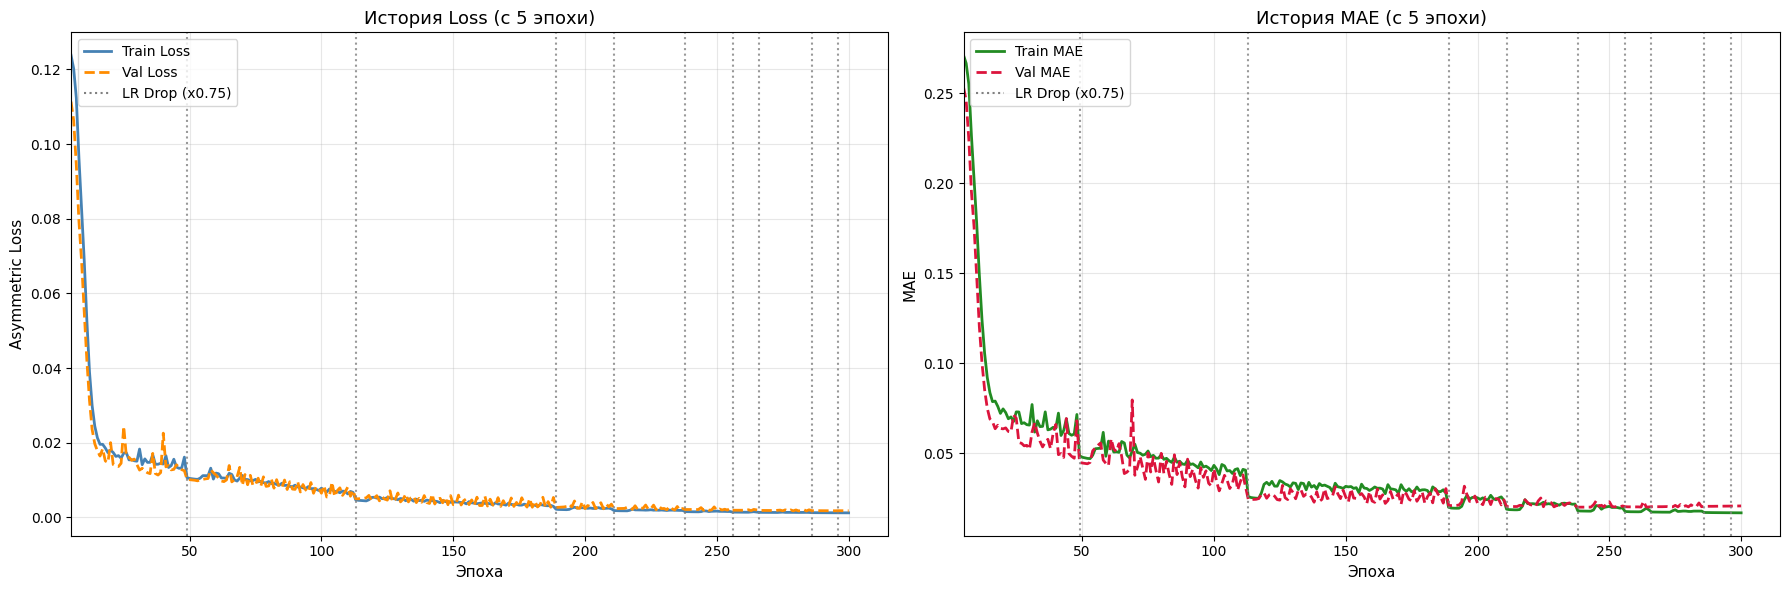

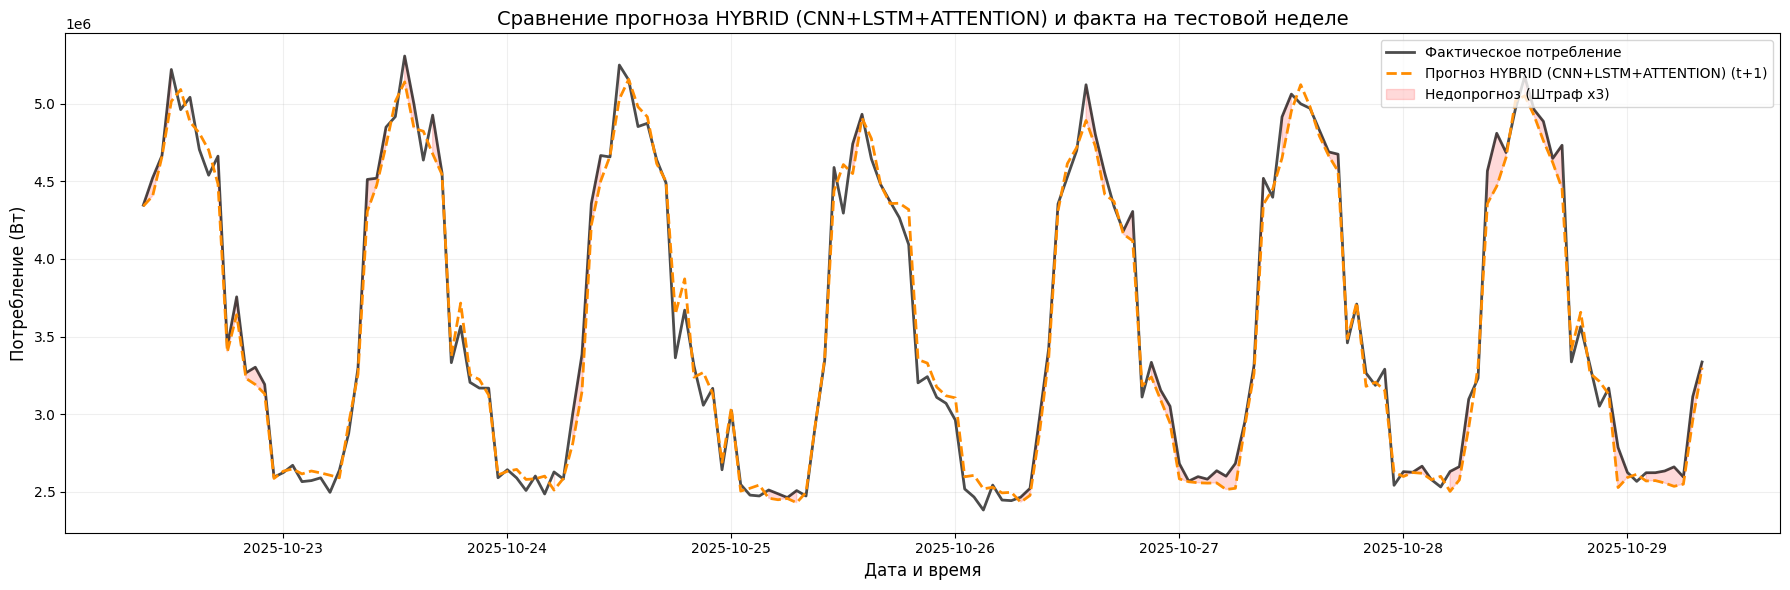

In [8]:
y_pred_log = model_hybrid.predict(X_test_scaled)
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

plot_training_history_with_lr(
    history_hybrid, 
    start_epoch=5, 
    save_path='data/13_hybrid_training_history.png'
)

metrics = evaluate_and_plot_predictions(
    y_test_real=y_test_real, 
    y_pred_real=y_pred_real, 
    dates_test=dates_test, 
    model_name="HYBRID (CNN+LSTM+ATTENTION)",
    save_path='data/14_hybrid_predictions.png'
)

# Сохранение весов

In [9]:
model_hybrid.save('model_weights/hybrid_model.keras')